# Assess immunoglobulin heavy-chain repertoire saturation

**Biology rationale.** Saturation analysis evaluates whether sequencing depth adequately captures the observed heavy-chain repertoire.

**Aim.** Subsample V(D)J contigs and generate clone-discovery saturation curves.

**Data input.** `all_contig_annotations.csv`, `Sample-to-BCR_mapping.csv`, `filtered_contig_annotations.csv`, `{sid}.saturation_curve_repeats.csv`, `{sid}.saturation_curve.pdf`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Packages and setup


In [1]:
import os
import pandas as pd
import numpy as np


In [2]:
def load_all_contigs_from_mapping(mapping_csv):
    mapping = pd.read_csv(mapping_csv)
    records = []

    for _, row in mapping.iterrows():
        sample_id = row["Sample_ID"]
        bcr_path  = row["BCR_File_Path"]
        folder    = os.path.dirname(bcr_path)

        fn = os.path.join(folder, "all_contig_annotations.csv")
        if not os.path.exists(fn):
            raise FileNotFoundError(fn)

        df = pd.read_csv(fn)
        df["sample_id"] = sample_id
        records.append(df)

    return pd.concat(records, ignore_index=True)


contigs = load_all_contigs_from_mapping("Sample-to-BCR_mapping.csv")
print(contigs.shape)


contigs_igh = contigs[contigs["chain"] == "IGH"].copy()

# productive only
# contigs_igh = contigs_igh[contigs_igh["productive"] == True]

# non-productive only
# contigs_igh = contigs_igh[contigs_igh["productive"] == False]


/tmp/ipykernel_48704/2146222749.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fn)


(958301, 32)


In [3]:
def expand_by_reads(df, feature_col="cdr3"):
    """
    Expand contigs into a read-weighted vector.
    """
    df = df.dropna(subset=[feature_col, "reads"]).copy()
    df["reads"] = df["reads"].astype(int)

    expanded = np.repeat(
        df[feature_col].values,
        df["reads"].values
    )
    return expanded


In [4]:
def saturation_curve_reads(
    expanded_features,
    n_steps=30,
    n_repeats=20,
    random_state=0,
):
    rng = np.random.default_rng(random_state)
    n_total = len(expanded_features)

    sample_sizes = np.unique(
        np.linspace(100, n_total, n_steps).astype(int)
    )

    rows = []

    for n in sample_sizes:
        for r in range(n_repeats):
            sample = rng.choice(expanded_features, size=n, replace=False)
            rows.append({
                "n_reads_sampled": n,
                "n_unique_features": len(np.unique(sample)),
                "repeat": r
            })

    return pd.DataFrame(rows)


/tmp/ipykernel_48704/57495204.py:25: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fn)


contigs shape: (958301, 32)


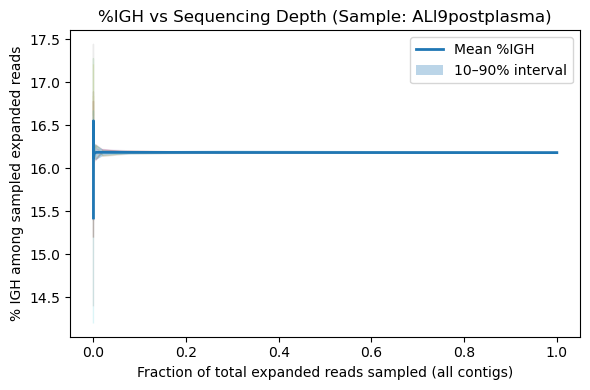

[Preview sample] ALl9postplasma
  Expanded total reads (rows): 52,200,228
  Full-depth %IGH (expanded): 16.18%
sat_all shape: (3500, 6)


,repeat,n_reads_sampled,total_reads,frac_total,pct_igh,sample_id
0,0,500,52200228,0.000010,15.200000,ALl9postplasma
1,0,1806,52200228,0.000035,15.393134,ALl9postplasma
2,0,6520,52200228,0.000125,16.518405,ALl9postplasma
3,0,23543,52200228,0.000451,16.132184,ALl9postplasma
4,0,85017,52200228,0.001629,16.134420,ALl9postplasma


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


# ============================================================
# 0) Load contigs (ALL contigs) from mapping -> one table
# ============================================================

def load_all_contigs_from_mapping(mapping_csv: str) -> pd.DataFrame:
    mapping = pd.read_csv(mapping_csv)
    records = []

    for _, row in mapping.iterrows():
        sample_id = row["Sample_ID"]
        bcr_path  = row["BCR_File_Path"]
        folder    = os.path.dirname(bcr_path)

        fn = os.path.join(folder, "all_contig_annotations.csv")
        if not os.path.exists(fn):
            raise FileNotFoundError(fn)

        df = pd.read_csv(fn)
        df["sample_id"] = sample_id
        records.append(df)

    return pd.concat(records, ignore_index=True)


# ============================================================
# 1) Expand contigs table by reads (row replication)
# ============================================================

def expand_by_reads(df: pd.DataFrame, reads_col: str = "reads") -> pd.DataFrame:
    """
    Repeat each row `reads_col` times.

    WARNING: can explode to massive size if total reads are large.
    """
    if reads_col not in df.columns:
        raise KeyError("Missing column '%s' in contigs table." % reads_col)

    w = pd.to_numeric(df[reads_col], errors="coerce").fillna(0).astype(np.int64)
    w = w.clip(lower=0)

    keep = w > 0
    df2 = df.loc[keep].copy()
    w2 = w.loc[keep].to_numpy()

    out = df2.loc[df2.index.repeat(w2)].reset_index(drop=True)
    return out


# ============================================================
# 2) Sample-by-sample saturation curve (%IGH vs fraction total reads)
# ============================================================

def saturation_curve_pct_igh_expanded(
    expanded_df: pd.DataFrame,
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    sizes: Optional[np.ndarray] = None,
) -> Optional[pd.DataFrame]:
    """
    expanded_df: expanded rows represent reads.
    Computes %IGH among sampled expanded reads vs fraction of total expanded reads sampled.
    Sampling: without replacement.
    """
    if chain_col not in expanded_df.columns:
        raise KeyError("Missing '%s' in expanded_df." % chain_col)

    N = int(len(expanded_df))
    if N < min_total_reads:
        return None

    is_igh = (expanded_df[chain_col].astype(str) == igh_value).to_numpy(dtype=bool)

    if sizes is None:
        sizes = np.unique(np.round(np.geomspace(min_total_reads, N, num=n_steps)).astype(int))
        sizes = sizes[(sizes > 0) & (sizes <= N)]
        if sizes.size == 0:
            sizes = np.array([min_total_reads, N], dtype=int)

    rng = np.random.default_rng(random_state)

    out = []
    for r in range(n_repeats):
        for m in sizes:
            m = int(min(int(m), N))
            idx = rng.choice(N, size=m, replace=False)
            pct = 100.0 * float(is_igh[idx].mean())
            out.append({
                "repeat": r,
                "n_reads_sampled": m,
                "total_reads": N,
                "frac_total": m / float(N),
                "pct_igh": pct,
            })

    return pd.DataFrame(out)


# ============================================================
# 3) Preview: first valid sample only (run + plot)
# ============================================================

def preview_first_sample_plot(
    contigs: pd.DataFrame,
    reads_col: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    first_sat = None
    first_sample_id = None
    first_expanded = None

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        first_sat = sat
        first_sample_id = sample_id
        first_expanded = expanded
        break

    if first_sat is None:
        raise ValueError(f"No sample had >= {min_total_reads} expanded reads; nothing to plot.")

    summary = (
        first_sat
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
    )

    plt.figure(figsize=(6, 4))
    for _, d in first_sat.sort_values("frac_total").groupby("repeat"):
        plt.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    plt.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    plt.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    plt.xlabel("Fraction of total expanded reads sampled (all contigs)")
    plt.ylabel("% IGH among sampled expanded reads")
    plt.title(f"%IGH vs Sequencing Depth (Sample: {first_sample_id})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    full_pct = 100.0 * float((first_expanded[chain_col].astype(str) == igh_value).mean())
    N = int(first_sat["total_reads"].iloc[0])

    print(f"[Preview sample] {first_sample_id}")
    print(f"  Expanded total reads (rows): {N:,}")
    print(f"  Full-depth %IGH (expanded): {full_pct:.2f}%")

    return first_sat

# ============================================================
# 4) Run sample-by-sample for ALL samples and store results
# ============================================================

def run_all_samples_saturation(
    contigs: pd.DataFrame,
    reads_col: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    all_sats = []

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        all_sats.append(sat)

    return pd.concat(all_sats, ignore_index=True) if all_sats else pd.DataFrame()


# ============================================================
# 5) MAIN
# ============================================================

contigs = load_all_contigs_from_mapping("Sample-to-BCR_mapping.csv")
print("contigs shape:", contigs.shape)

# Pick reads column robustly
if "reads" in contigs.columns:
    READS_COL = "reads"
elif "umis" in contigs.columns:
    READS_COL = "umis"
else:
    raise KeyError("Could not find reads column. Expected 'reads' or 'umis'.")

# (2) Preview first valid sample
first_sat = preview_first_sample_plot(
    contigs,
    reads_col=READS_COL,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

# (3) Run all samples and store results
sat_all = run_all_samples_saturation(
    contigs,
    reads_col=READS_COL,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

print("sat_all shape:", sat_all.shape)
display(sat_all.head() if hasattr(__builtins__, "display") else sat_all.head())


## 2. Clonotype assignment and repertoire analysis


contigs shape: (376820, 32)


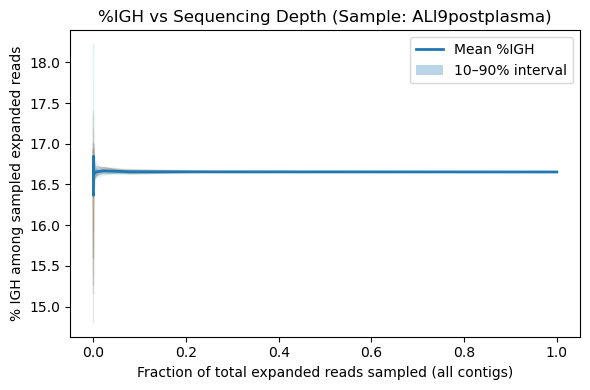

[Preview sample] ALl9postplasma
  Expanded total reads (rows): 48,115,944
  Full-depth %IGH (expanded): 16.65%
sat_all shape: (3500, 6)


,repeat,n_reads_sampled,total_reads,frac_total,pct_igh,sample_id
0,0,500,48115944,0.000010,17.400000,ALl9postplasma
1,0,1789,48115944,0.000037,15.259922,ALl9postplasma
2,0,6403,48115944,0.000133,17.007653,ALl9postplasma
3,0,22913,48115944,0.000476,16.453542,ALl9postplasma
4,0,81993,48115944,0.001704,16.620931,ALl9postplasma


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


# ============================================================
# 0) Load contigs (ALL contigs) from mapping -> one table
# ============================================================

def load_all_contigs_from_mapping(mapping_csv: str) -> pd.DataFrame:
    mapping = pd.read_csv(mapping_csv)
    records = []

    for _, row in mapping.iterrows():
        sample_id = row["Sample_ID"]
        bcr_path  = row["BCR_File_Path"]
        folder    = os.path.dirname(bcr_path)

        fn = os.path.join(folder, "filtered_contig_annotations.csv")
        if not os.path.exists(fn):
            raise FileNotFoundError(fn)

        df = pd.read_csv(fn)
        df["sample_id"] = sample_id
        records.append(df)

    return pd.concat(records, ignore_index=True)


# ============================================================
# 1) Expand contigs table by reads (row replication)
# ============================================================

def expand_by_reads(df: pd.DataFrame, reads_col: str = "reads") -> pd.DataFrame:
    """
    Repeat each row `reads_col` times.

    WARNING: can explode to massive size if total reads are large.
    """
    if reads_col not in df.columns:
        raise KeyError("Missing column '%s' in contigs table." % reads_col)

    w = pd.to_numeric(df[reads_col], errors="coerce").fillna(0).astype(np.int64)
    w = w.clip(lower=0)

    keep = w > 0
    df2 = df.loc[keep].copy()
    w2 = w.loc[keep].to_numpy()

    out = df2.loc[df2.index.repeat(w2)].reset_index(drop=True)
    return out


# ============================================================
# 2) Sample-by-sample saturation curve (%IGH vs fraction total reads)
# ============================================================

def saturation_curve_pct_igh_expanded(
    expanded_df: pd.DataFrame,
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    sizes: Optional[np.ndarray] = None,
) -> Optional[pd.DataFrame]:
    """
    expanded_df: expanded rows represent reads.
    Computes %IGH among sampled expanded reads vs fraction of total expanded reads sampled.
    Sampling: without replacement.
    """
    if chain_col not in expanded_df.columns:
        raise KeyError("Missing '%s' in expanded_df." % chain_col)

    N = int(len(expanded_df))
    if N < min_total_reads:
        return None

    is_igh = (expanded_df[chain_col].astype(str) == igh_value).to_numpy(dtype=bool)

    if sizes is None:
        sizes = np.unique(np.round(np.geomspace(min_total_reads, N, num=n_steps)).astype(int))
        sizes = sizes[(sizes > 0) & (sizes <= N)]
        if sizes.size == 0:
            sizes = np.array([min_total_reads, N], dtype=int)

    rng = np.random.default_rng(random_state)

    out = []
    for r in range(n_repeats):
        for m in sizes:
            m = int(min(int(m), N))
            idx = rng.choice(N, size=m, replace=False)
            pct = 100.0 * float(is_igh[idx].mean())
            out.append({
                "repeat": r,
                "n_reads_sampled": m,
                "total_reads": N,
                "frac_total": m / float(N),
                "pct_igh": pct,
            })

    return pd.DataFrame(out)


# ============================================================
# 3) Preview: first valid sample only (run + plot)
# ============================================================

def preview_first_sample_plot(
    contigs: pd.DataFrame,
    reads_col: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    first_sat = None
    first_sample_id = None
    first_expanded = None

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        first_sat = sat
        first_sample_id = sample_id
        first_expanded = expanded
        break

    if first_sat is None:
        raise ValueError(f"No sample had >= {min_total_reads} expanded reads; nothing to plot.")

    summary = (
        first_sat
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
    )

    plt.figure(figsize=(6, 4))
    for _, d in first_sat.sort_values("frac_total").groupby("repeat"):
        plt.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    plt.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    plt.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    plt.xlabel("Fraction of total expanded reads sampled (all contigs)")
    plt.ylabel("% IGH among sampled expanded reads")
    plt.title(f"%IGH vs Sequencing Depth (Sample: {first_sample_id})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    full_pct = 100.0 * float((first_expanded[chain_col].astype(str) == igh_value).mean())
    N = int(first_sat["total_reads"].iloc[0])

    print(f"[Preview sample] {first_sample_id}")
    print(f"  Expanded total reads (rows): {N:,}")
    print(f"  Full-depth %IGH (expanded): {full_pct:.2f}%")

    return first_sat

# ============================================================
# 4) Run sample-by-sample for ALL samples and store results
# ============================================================

def run_all_samples_saturation(
    contigs: pd.DataFrame,
    reads_col: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    all_sats = []

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        all_sats.append(sat)

    return pd.concat(all_sats, ignore_index=True) if all_sats else pd.DataFrame()


# ============================================================
# 5) MAIN
# ============================================================

contigs = load_all_contigs_from_mapping("Sample-to-BCR_mapping.csv")
print("contigs shape:", contigs.shape)

# Pick reads column robustly
if "reads" in contigs.columns:
    READS_COL = "reads"
elif "umis" in contigs.columns:
    READS_COL = "umis"
else:
    raise KeyError("Could not find reads column. Expected 'reads' or 'umis'.")

# (2) Preview first valid sample
first_sat = preview_first_sample_plot(
    contigs,
    reads_col=READS_COL,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

# (3) Run all samples and store results
sat_all = run_all_samples_saturation(
    contigs,
    reads_col=READS_COL,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

print("sat_all shape:", sat_all.shape)
display(sat_all.head() if hasattr(__builtins__, "display") else sat_all.head())


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Tuple

# ============================================================
# 0) Load contigs (ALL contigs) from mapping -> one table
# ============================================================

def load_all_contigs_from_mapping(mapping_csv: str) -> pd.DataFrame:
    mapping = pd.read_csv(mapping_csv)
    records = []

    for _, row in mapping.iterrows():
        sample_id = row["Sample_ID"]
        bcr_path  = row["BCR_File_Path"]
        folder    = os.path.dirname(bcr_path)

        fn = os.path.join(folder, "filtered_contig_annotations.csv")
        if not os.path.exists(fn):
            raise FileNotFoundError(fn)

        df = pd.read_csv(fn)
        df["sample_id"] = sample_id
        records.append(df)

    return pd.concat(records, ignore_index=True)


# ============================================================
# 1) Expand contigs table by reads/umis (row replication)
# ============================================================

def expand_by_reads(df: pd.DataFrame, reads_col: str = "reads") -> pd.DataFrame:
    """
    Repeat each row `reads_col` times.

    WARNING: can explode to massive size if total reads are large.
    """
    if reads_col not in df.columns:
        raise KeyError(f"Missing column '{reads_col}' in contigs table.")

    w = pd.to_numeric(df[reads_col], errors="coerce").fillna(0).astype(np.int64).clip(lower=0)
    keep = w > 0
    df2 = df.loc[keep].copy()
    w2 = w.loc[keep].to_numpy()

    out = df2.loc[df2.index.repeat(w2)].reset_index(drop=True)
    return out


# ============================================================
# 2) Sample-by-sample saturation curve (%IGH vs fraction total reads)
# ============================================================

def saturation_curve_pct_igh_expanded(
    expanded_df: pd.DataFrame,
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    sizes: Optional[np.ndarray] = None,
) -> Optional[pd.DataFrame]:
    """
    expanded_df: expanded rows represent reads.
    Computes %IGH among sampled expanded reads vs fraction of total expanded reads sampled.
    Sampling: without replacement.
    """
    if chain_col not in expanded_df.columns:
        raise KeyError(f"Missing '{chain_col}' in expanded_df.")

    N = int(len(expanded_df))
    if N < min_total_reads:
        return None

    is_igh = (expanded_df[chain_col].astype(str) == igh_value).to_numpy(dtype=bool)

    if sizes is None:
        sizes = np.unique(np.round(np.geomspace(min_total_reads, N, num=n_steps)).astype(int))
        sizes = sizes[(sizes > 0) & (sizes <= N)]
        if sizes.size == 0:
            sizes = np.array([min_total_reads, N], dtype=int)

    rng = np.random.default_rng(random_state)

    out = []
    for r in range(n_repeats):
        for m in sizes:
            m = int(min(int(m), N))
            idx = rng.choice(N, size=m, replace=False)
            pct = 100.0 * float(is_igh[idx].mean())
            out.append({
                "repeat": r,
                "n_reads_sampled": m,
                "total_reads": N,
                "frac_total": m / float(N),
                "pct_igh": pct,
            })

    return pd.DataFrame(out)


# ============================================================
# 3) Plot helpers (return fig + summary)
# ============================================================

def summarize_curve(sat_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize repeats at each frac_total (mean + 10/90%).
    Assumes sat_df has pct_igh, frac_total.
    """
    return (
        sat_df
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_sample_curve(sat_df: pd.DataFrame, sample_id: str, *, show_repeats: bool = True) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Build a figure for one sample + return summarized curve table.
    """
    summary = summarize_curve(sat_df)

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    if show_repeats:
        for _, d in sat_df.sort_values("frac_total").groupby("repeat"):
            ax.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    ax.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    ax.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title(f"%IGH vs Sequencing Depth (Sample: {sample_id})")
    ax.legend()
    fig.tight_layout()
    return fig, summary


# ============================================================
# 4) Preview: first valid sample only (run + save + return)
# ============================================================

def preview_first_sample(
    contigs: pd.DataFrame,
    reads_col: str,
    out_fig_pdf: str,
    out_csv: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    first_sat = None
    first_sample_id = None
    first_expanded = None

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        first_sat = sat
        first_sample_id = sample_id
        first_expanded = expanded
        break

    if first_sat is None:
        raise ValueError(f"No sample had >= {min_total_reads} expanded reads; nothing to plot.")

    # Save table
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    first_sat.to_csv(out_csv, index=False)

    # Save figure
    fig, _summary = plot_sample_curve(first_sat, first_sample_id, show_repeats=True)
    os.makedirs(os.path.dirname(out_fig_pdf), exist_ok=True)
    fig.savefig(out_fig_pdf, bbox_inches="tight")
    plt.close(fig)

    full_pct = 100.0 * float((first_expanded[chain_col].astype(str) == igh_value).mean())
    N = int(first_sat["total_reads"].iloc[0])

    print(f"[Preview sample] {first_sample_id}")
    print(f"  Expanded total reads (rows): {N:,}")
    print(f"  Full-depth %IGH (expanded): {full_pct:.2f}%")
    print(f"  Saved: {out_fig_pdf}")
    print(f"  Saved: {out_csv}")

    return first_sat


def run_all_samples_saturation_and_save_one_by_one(
    contigs: pd.DataFrame,
    reads_col: str,
    out_sat_all_csv: str,
    out_per_sample_summary_csv: str,
    figdir: str,
    tabdir: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    filename_safe: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Saves per-sample outputs ONE BY ONE using sample_id as filename prefix.

    Per sample:
      - {figdir}/{sample_id}.saturation_curve.pdf
      - {tabdir}/{sample_id}.saturation_curve_repeats.csv
      - {tabdir}/{sample_id}.saturation_curve_summary.csv

    Also saves:
      - out_sat_all_csv (all repeats for all samples)
      - out_per_sample_summary_csv (summary for all samples)
    """
    def _safe(s: str) -> str:
        if not filename_safe:
            return s
        # conservative filename sanitization
        s = str(s)
        s = s.replace(os.sep, "_")
        s = s.replace(" ", "_")
        for ch in ['"', "'", ":", ";", "|", "?", "*", "<", ">", "\\"]:
            s = s.replace(ch, "_")
        return s

    os.makedirs(os.path.dirname(out_sat_all_csv), exist_ok=True)
    os.makedirs(os.path.dirname(out_per_sample_summary_csv), exist_ok=True)
    os.makedirs(figdir, exist_ok=True)
    os.makedirs(tabdir, exist_ok=True)

    all_sats = []
    per_sample_summaries = []

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        all_sats.append(sat)

        # ---- per-sample table (repeats)
        sid = _safe(sample_id)
        repeats_csv = os.path.join(tabdir, f"{sid}.saturation_curve_repeats.csv")
        sat.to_csv(repeats_csv, index=False)

        # ---- per-sample plot + summary table
        fig, summary = plot_sample_curve(sat, sample_id, show_repeats=True)

        fig_pdf = os.path.join(figdir, f"{sid}.saturation_curve.pdf")
        fig.savefig(fig_pdf, bbox_inches="tight")
        plt.close(fig)

        summary[sample_col] = sample_id
        per_sample_summaries.append(summary)

        summary_csv = os.path.join(tabdir, f"{sid}.saturation_curve_summary.csv")
        summary.to_csv(summary_csv, index=False)

        print(f"[Saved per-sample] {sample_id}")
        print(f"  Plot:    {fig_pdf}")
        print(f"  Repeats: {repeats_csv}")
        print(f"  Summary: {summary_csv}")

    sat_all = pd.concat(all_sats, ignore_index=True) if all_sats else pd.DataFrame()
    per_sample_summary = pd.concat(per_sample_summaries, ignore_index=True) if per_sample_summaries else pd.DataFrame()

    sat_all.to_csv(out_sat_all_csv, index=False)
    per_sample_summary.to_csv(out_per_sample_summary_csv, index=False)

    print(f"Saved (all samples repeats): {out_sat_all_csv}")
    print(f"Saved (all samples summary): {out_per_sample_summary_csv}")

    return sat_all, per_sample_summary

# ============================================================
# 6) All-sample average curve + plot
# ============================================================

def compute_all_samples_average_curve(per_sample_summary: pd.DataFrame, sample_col: str = "sample_id") -> pd.DataFrame:
    """
    Average across samples at each frac_total using the per-sample mean curve.
    (Unweighted average across samples.)
    """
    if per_sample_summary.empty:
        return per_sample_summary

    avg = (
        per_sample_summary
        .groupby("frac_total", as_index=False)
        .agg(
            avg_mean_pct_igh=("mean_pct_igh", "mean"),
            p10_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.10)),
            p90_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )
    return avg

def plot_all_samples_average_curve(avg_curve: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    ax.plot(avg_curve["frac_total"], avg_curve["avg_mean_pct_igh"], linewidth=2, label="Average of sample means")
    ax.fill_between(avg_curve["frac_total"], avg_curve["p10_of_means"], avg_curve["p90_of_means"], alpha=0.3,
                    label="10–90% across samples (means)")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title("%IGH vs Sequencing Depth (Average across samples)")
    ax.legend()
    fig.tight_layout()
    return fig


# ============================================================
# 7) MAIN (with outputs)
# ============================================================

OUTDIR = "saturation_outputs"
FIGDIR = os.path.join(OUTDIR, "figures")
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

contigs = load_all_contigs_from_mapping("Sample-to-BCR_mapping.csv")
print("contigs shape:", contigs.shape)

# Optional: save loaded contigs (can be large)
# contigs.to_csv(os.path.join(TABDIR, "contigs_loaded.csv"), index=False)

# Pick reads column robustly
if "reads" in contigs.columns:
    READS_COL = "reads"
else:
    raise KeyError("Could not find reads column. Expected 'reads'.")

# (A) Preview first valid sample: save fig + csv
first_sat = preview_first_sample(
    contigs,
    reads_col=READS_COL,
    out_fig_pdf=os.path.join(FIGDIR, "preview_first_sample.pdf"),
    out_csv=os.path.join(TABDIR, "first_sample_sat.csv"),
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

# (B) Run all samples: save sat_all + per-sample PDF + per-sample curve summary table
sat_all, per_sample_summary = run_all_samples_saturation_and_save_one_by_one(
    contigs,
    reads_col=READS_COL,
    out_sat_all_csv=os.path.join(TABDIR, "sat_all.csv"),
    out_per_sample_summary_csv=os.path.join(TABDIR, "per_sample_curve_summary.csv"),
    figdir=FIGDIR,
    tabdir=TABDIR,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

print("sat_all shape:", sat_all.shape)

# (C) All-sample average curve: save table + figure
avg_curve = compute_all_samples_average_curve(per_sample_summary, sample_col="sample_id")
avg_curve.to_csv(os.path.join(TABDIR, "all_samples_average_curve.csv"), index=False)

fig_avg = plot_all_samples_average_curve(avg_curve)
fig_avg.savefig(os.path.join(FIGDIR, "all_samples_average_curve.pdf"), bbox_inches="tight")
plt.close(fig_avg)

print(f"Saved: {os.path.join(TABDIR, 'all_samples_average_curve.csv')}")
print(f"Saved: {os.path.join(FIGDIR, 'all_samples_average_curve.pdf')}")

# If you want to display a quick head:
print(avg_curve.head())


contigs shape: (376820, 32)
[Preview sample] ALl9postplasma
  Expanded total reads (rows): 48,115,944
  Full-depth %IGH (expanded): 16.65%
  Saved: saturation_outputs/figures/preview_first_sample.pdf
  Saved: saturation_outputs/tables/first_sample_sat.csv
[Saved per-sample] ALl9postplasma
  Plot:    saturation_outputs/figures/ALl9postplasma.saturation_curve.pdf
  Repeats: saturation_outputs/tables/ALl9postplasma.saturation_curve_repeats.csv
  Summary: saturation_outputs/tables/ALl9postplasma.saturation_curve_summary.csv
[Saved per-sample] ALk2plasma
  Plot:    saturation_outputs/figures/ALk2plasma.saturation_curve.pdf
  Repeats: saturation_outputs/tables/ALk2plasma.saturation_curve_repeats.csv
  Summary: saturation_outputs/tables/ALk2plasma.saturation_curve_summary.csv
[Saved per-sample] ALk3preplasma
  Plot:    saturation_outputs/figures/ALk3preplasma.saturation_curve.pdf
  Repeats: saturation_outputs/tables/ALk3preplasma.saturation_curve_repeats.csv
  Summary: saturation_outputs/tabl

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Tuple

# ============================================================
# 0) Load contigs (ALL contigs) from mapping -> one table
# ============================================================

def load_all_contigs_from_mapping(mapping_csv: str) -> pd.DataFrame:
    mapping = pd.read_csv(mapping_csv)
    records = []

    for _, row in mapping.iterrows():
        sample_id = row["Sample_ID"]
        bcr_path  = row["BCR_File_Path"]
        folder    = os.path.dirname(bcr_path)

        fn = os.path.join(folder, "all_contig_annotations.csv")
        if not os.path.exists(fn):
            raise FileNotFoundError(fn)

        df = pd.read_csv(fn)
        df["sample_id"] = sample_id
        records.append(df)

    return pd.concat(records, ignore_index=True)


# ============================================================
# 1) Expand contigs table by reads/umis (row replication)
# ============================================================

def expand_by_reads(df: pd.DataFrame, reads_col: str = "reads") -> pd.DataFrame:
    """
    Repeat each row `reads_col` times.

    WARNING: can explode to massive size if total reads are large.
    """
    if reads_col not in df.columns:
        raise KeyError(f"Missing column '{reads_col}' in contigs table.")

    w = pd.to_numeric(df[reads_col], errors="coerce").fillna(0).astype(np.int64).clip(lower=0)
    keep = w > 0
    df2 = df.loc[keep].copy()
    w2 = w.loc[keep].to_numpy()

    out = df2.loc[df2.index.repeat(w2)].reset_index(drop=True)
    return out


# ============================================================
# 2) Sample-by-sample saturation curve (%IGH vs fraction total reads)
# ============================================================

def saturation_curve_pct_igh_expanded(
    expanded_df: pd.DataFrame,
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    sizes: Optional[np.ndarray] = None,
) -> Optional[pd.DataFrame]:
    """
    expanded_df: expanded rows represent reads.
    Computes %IGH among sampled expanded reads vs fraction of total expanded reads sampled.
    Sampling: without replacement.
    """
    if chain_col not in expanded_df.columns:
        raise KeyError(f"Missing '{chain_col}' in expanded_df.")

    N = int(len(expanded_df))
    if N < min_total_reads:
        return None

    is_igh = (expanded_df[chain_col].astype(str) == igh_value).to_numpy(dtype=bool)

    if sizes is None:
        sizes = np.unique(np.round(np.geomspace(min_total_reads, N, num=n_steps)).astype(int))
        sizes = sizes[(sizes > 0) & (sizes <= N)]
        if sizes.size == 0:
            sizes = np.array([min_total_reads, N], dtype=int)

    rng = np.random.default_rng(random_state)

    out = []
    for r in range(n_repeats):
        for m in sizes:
            m = int(min(int(m), N))
            idx = rng.choice(N, size=m, replace=False)
            pct = 100.0 * float(is_igh[idx].mean())
            out.append({
                "repeat": r,
                "n_reads_sampled": m,
                "total_reads": N,
                "frac_total": m / float(N),
                "pct_igh": pct,
            })

    return pd.DataFrame(out)


# ============================================================
# 3) Plot helpers (return fig + summary)
# ============================================================

def summarize_curve(sat_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize repeats at each frac_total (mean + 10/90%).
    Assumes sat_df has pct_igh, frac_total.
    """
    return (
        sat_df
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_sample_curve(sat_df: pd.DataFrame, sample_id: str, *, show_repeats: bool = True) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Build a figure for one sample + return summarized curve table.
    """
    summary = summarize_curve(sat_df)

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    if show_repeats:
        for _, d in sat_df.sort_values("frac_total").groupby("repeat"):
            ax.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    ax.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    ax.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title(f"%IGH vs Sequencing Depth (Sample: {sample_id})")
    ax.legend()
    fig.tight_layout()
    return fig, summary


# ============================================================
# 4) Preview: first valid sample only (run + save + return)
# ============================================================

def preview_first_sample(
    contigs: pd.DataFrame,
    reads_col: str,
    out_fig_pdf: str,
    out_csv: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
) -> pd.DataFrame:

    first_sat = None
    first_sample_id = None
    first_expanded = None

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        first_sat = sat
        first_sample_id = sample_id
        first_expanded = expanded
        break

    if first_sat is None:
        raise ValueError(f"No sample had >= {min_total_reads} expanded reads; nothing to plot.")

    # Save table
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    first_sat.to_csv(out_csv, index=False)

    # Save figure
    fig, _summary = plot_sample_curve(first_sat, first_sample_id, show_repeats=True)
    os.makedirs(os.path.dirname(out_fig_pdf), exist_ok=True)
    fig.savefig(out_fig_pdf, bbox_inches="tight")
    plt.close(fig)

    full_pct = 100.0 * float((first_expanded[chain_col].astype(str) == igh_value).mean())
    N = int(first_sat["total_reads"].iloc[0])

    print(f"[Preview sample] {first_sample_id}")
    print(f"  Expanded total reads (rows): {N:,}")
    print(f"  Full-depth %IGH (expanded): {full_pct:.2f}%")
    print(f"  Saved: {out_fig_pdf}")
    print(f"  Saved: {out_csv}")

    return first_sat


def run_all_samples_saturation_and_save_one_by_one(
    contigs: pd.DataFrame,
    reads_col: str,
    out_sat_all_csv: str,
    out_per_sample_summary_csv: str,
    figdir: str,
    tabdir: str,
    sample_col: str = "sample_id",
    chain_col: str = "chain",
    igh_value: str = "IGH",
    n_steps: int = 10,
    n_repeats: int = 10,
    random_state: int = 1,
    min_total_reads: int = 500,
    filename_safe: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Saves per-sample outputs ONE BY ONE using sample_id as filename prefix.

    Per sample:
      - {figdir}/{sample_id}.saturation_curve.pdf
      - {tabdir}/{sample_id}.saturation_curve_repeats.csv
      - {tabdir}/{sample_id}.saturation_curve_summary.csv

    Also saves:
      - out_sat_all_csv (all repeats for all samples)
      - out_per_sample_summary_csv (summary for all samples)
    """
    def _safe(s: str) -> str:
        if not filename_safe:
            return s
        # conservative filename sanitization
        s = str(s)
        s = s.replace(os.sep, "_")
        s = s.replace(" ", "_")
        for ch in ['"', "'", ":", ";", "|", "?", "*", "<", ">", "\\"]:
            s = s.replace(ch, "_")
        return s

    os.makedirs(os.path.dirname(out_sat_all_csv), exist_ok=True)
    os.makedirs(os.path.dirname(out_per_sample_summary_csv), exist_ok=True)
    os.makedirs(figdir, exist_ok=True)
    os.makedirs(tabdir, exist_ok=True)

    all_sats = []
    per_sample_summaries = []

    for sample_id, df_s in contigs.groupby(sample_col, sort=False):
        expanded = expand_by_reads(df_s, reads_col=reads_col)

        sat = saturation_curve_pct_igh_expanded(
            expanded,
            chain_col=chain_col,
            igh_value=igh_value,
            n_steps=n_steps,
            n_repeats=n_repeats,
            random_state=random_state,
            min_total_reads=min_total_reads,
        )
        if sat is None:
            continue

        sat[sample_col] = sample_id
        all_sats.append(sat)

        # ---- per-sample table (repeats)
        sid = _safe(sample_id)
        repeats_csv = os.path.join(tabdir, f"{sid}.saturation_curve_repeats.csv")
        sat.to_csv(repeats_csv, index=False)

        # ---- per-sample plot + summary table
        fig, summary = plot_sample_curve(sat, sample_id, show_repeats=True)

        fig_pdf = os.path.join(figdir, f"{sid}.saturation_curve.pdf")
        fig.savefig(fig_pdf, bbox_inches="tight")
        plt.close(fig)

        summary[sample_col] = sample_id
        per_sample_summaries.append(summary)

        summary_csv = os.path.join(tabdir, f"{sid}.saturation_curve_summary.csv")
        summary.to_csv(summary_csv, index=False)

        print(f"[Saved per-sample] {sample_id}")
        print(f"  Plot:    {fig_pdf}")
        print(f"  Repeats: {repeats_csv}")
        print(f"  Summary: {summary_csv}")

    sat_all = pd.concat(all_sats, ignore_index=True) if all_sats else pd.DataFrame()
    per_sample_summary = pd.concat(per_sample_summaries, ignore_index=True) if per_sample_summaries else pd.DataFrame()

    sat_all.to_csv(out_sat_all_csv, index=False)
    per_sample_summary.to_csv(out_per_sample_summary_csv, index=False)

    print(f"Saved (all samples repeats): {out_sat_all_csv}")
    print(f"Saved (all samples summary): {out_per_sample_summary_csv}")

    return sat_all, per_sample_summary

# ============================================================
# 6) All-sample average curve + plot
# ============================================================

def compute_all_samples_average_curve(per_sample_summary: pd.DataFrame, sample_col: str = "sample_id") -> pd.DataFrame:
    """
    Average across samples at each frac_total using the per-sample mean curve.
    (Unweighted average across samples.)
    """
    if per_sample_summary.empty:
        return per_sample_summary

    avg = (
        per_sample_summary
        .groupby("frac_total", as_index=False)
        .agg(
            avg_mean_pct_igh=("mean_pct_igh", "mean"),
            p10_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.10)),
            p90_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )
    return avg

def plot_all_samples_average_curve(avg_curve: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    ax.plot(avg_curve["frac_total"], avg_curve["avg_mean_pct_igh"], linewidth=2, label="Average of sample means")
    ax.fill_between(avg_curve["frac_total"], avg_curve["p10_of_means"], avg_curve["p90_of_means"], alpha=0.3,
                    label="10–90% across samples (means)")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title("%IGH vs Sequencing Depth (Average across samples)")
    ax.legend()
    fig.tight_layout()
    return fig


# ============================================================
# 7) MAIN (with outputs)
# ============================================================

OUTDIR = "saturation_outputs_allcontigs"
FIGDIR = os.path.join(OUTDIR, "figures")
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

contigs = load_all_contigs_from_mapping("Sample-to-BCR_mapping.csv")
print("contigs shape:", contigs.shape)

# Optional: save loaded contigs (can be large)
# contigs.to_csv(os.path.join(TABDIR, "contigs_loaded.csv"), index=False)

# Pick reads column robustly
if "reads" in contigs.columns:
    READS_COL = "reads"
else:
    raise KeyError("Could not find reads column. Expected 'reads'.")

# (A) Preview first valid sample: save fig + csv
first_sat = preview_first_sample(
    contigs,
    reads_col=READS_COL,
    out_fig_pdf=os.path.join(FIGDIR, "preview_first_sample.pdf"),
    out_csv=os.path.join(TABDIR, "first_sample_sat.csv"),
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

# (B) Run all samples: save sat_all + per-sample PDF + per-sample curve summary table
sat_all, per_sample_summary = run_all_samples_saturation_and_save_one_by_one(
    contigs,
    reads_col=READS_COL,
    out_sat_all_csv=os.path.join(TABDIR, "sat_all.csv"),
    out_per_sample_summary_csv=os.path.join(TABDIR, "per_sample_curve_summary.csv"),
    figdir=FIGDIR,
    tabdir=TABDIR,
    n_steps=10,
    n_repeats=10,
    random_state=1,
    min_total_reads=500,
)

print("sat_all shape:", sat_all.shape)

# (C) All-sample average curve: save table + figure
avg_curve = compute_all_samples_average_curve(per_sample_summary, sample_col="sample_id")
avg_curve.to_csv(os.path.join(TABDIR, "all_samples_average_curve.csv"), index=False)

fig_avg = plot_all_samples_average_curve(avg_curve)
fig_avg.savefig(os.path.join(FIGDIR, "all_samples_average_curve.pdf"), bbox_inches="tight")
plt.close(fig_avg)

print(f"Saved: {os.path.join(TABDIR, 'all_samples_average_curve.csv')}")
print(f"Saved: {os.path.join(FIGDIR, 'all_samples_average_curve.pdf')}")

# If you want to display a quick head:
print(avg_curve.head())


/tmp/ipykernel_48704/3323372948.py:24: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fn)


contigs shape: (958301, 32)
[Preview sample] ALl9postplasma
  Expanded total reads (rows): 52,200,228
  Full-depth %IGH (expanded): 16.18%
  Saved: saturation_outputs_allcontigs/figures/preview_first_sample.pdf
  Saved: saturation_outputs_allcontigs/tables/first_sample_sat.csv
[Saved per-sample] ALl9postplasma
  Plot:    saturation_outputs_allcontigs/figures/ALl9postplasma.saturation_curve.pdf
  Repeats: saturation_outputs_allcontigs/tables/ALl9postplasma.saturation_curve_repeats.csv
  Summary: saturation_outputs_allcontigs/tables/ALl9postplasma.saturation_curve_summary.csv
[Saved per-sample] ALk2plasma
  Plot:    saturation_outputs_allcontigs/figures/ALk2plasma.saturation_curve.pdf
  Repeats: saturation_outputs_allcontigs/tables/ALk2plasma.saturation_curve_repeats.csv
  Summary: saturation_outputs_allcontigs/tables/ALk2plasma.saturation_curve_summary.csv
[Saved per-sample] ALk3preplasma
  Plot:    saturation_outputs_allcontigs/figures/ALk3preplasma.saturation_curve.pdf
  Repeats: satu

## 3. Paths


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Paths
# -------------------------
OUTDIR = "saturation_outputs_allcontigs"
TABDIR = os.path.join(OUTDIR, "tables")
FIGDIR = os.path.join(OUTDIR, "figures_from_sat_all")
TABDIR2 = os.path.join(OUTDIR, "tables_from_sat_all")

os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR2, exist_ok=True)

SAT_ALL_CSV = os.path.join(TABDIR, "sat_all.csv")
if not os.path.exists(SAT_ALL_CSV):
    raise FileNotFoundError(SAT_ALL_CSV)

# -------------------------
# Load
# -------------------------
sat_all = pd.read_csv(SAT_ALL_CSV)
required = {"sample_id", "repeat", "frac_total", "pct_igh"}
missing = required - set(sat_all.columns)
if missing:
    raise KeyError(f"sat_all.csv missing columns: {missing}")

# Ensure numeric
sat_all["frac_total"] = pd.to_numeric(sat_all["frac_total"], errors="coerce")
sat_all["pct_igh"] = pd.to_numeric(sat_all["pct_igh"], errors="coerce")
sat_all = sat_all.dropna(subset=["sample_id", "repeat", "frac_total", "pct_igh"]).copy()

# -------------------------
# Helpers (same logic as before)
# -------------------------
def summarize_curve(sat_df: pd.DataFrame) -> pd.DataFrame:
    return (
        sat_df
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_sample_curve_from_sat(sat_df: pd.DataFrame, sample_id: str, show_repeats: bool = True):
    summary = summarize_curve(sat_df)

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    if show_repeats:
        for _, d in sat_df.sort_values("frac_total").groupby("repeat"):
            ax.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    ax.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    ax.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title(f"%IGH vs Sequencing Depth (Sample: {sample_id})")
    ax.legend()
    fig.tight_layout()
    return fig, summary

def normalize_per_sample_curve_to_full_depth(per_sample_summary: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    df = per_sample_summary.copy()
    full = (
        df.sort_values("frac_total")
          .groupby("sample_id", as_index=False)
          .tail(1)[["sample_id", "mean_pct_igh"]]
          .rename(columns={"mean_pct_igh": "full_depth_mean_pct_igh"})
    )
    df = df.merge(full, on="sample_id", how="left")

    denom = df["full_depth_mean_pct_igh"].astype(float)
    denom = denom.where(denom.abs() > eps, np.nan)
    df["mean_pct_igh_scaled"] = df["mean_pct_igh"].astype(float) / denom
    return df

def compute_avg_curve(per_sample_summary: pd.DataFrame) -> pd.DataFrame:
    return (
        per_sample_summary
        .groupby("frac_total", as_index=False)
        .agg(
            avg_mean_pct_igh=("mean_pct_igh", "mean"),
            p10_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.10)),
            p90_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def compute_avg_curve_scaled(per_sample_summary_scaled: pd.DataFrame) -> pd.DataFrame:
    return (
        per_sample_summary_scaled
        .groupby("frac_total", as_index=False)
        .agg(
            avg_scaled=("mean_pct_igh_scaled", "mean"),
            p10_scaled=("mean_pct_igh_scaled", lambda x: np.quantile(x, 0.10)),
            p90_scaled=("mean_pct_igh_scaled", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh_scaled", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_avg_curve(avg: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    ax.plot(avg["frac_total"], avg["avg_mean_pct_igh"], linewidth=2, label="Average of sample means")
    ax.fill_between(avg["frac_total"], avg["p10_of_means"], avg["p90_of_means"], alpha=0.3,
                    label="10–90% across samples (means)")
    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title("%IGH vs Sequencing Depth (Average across samples)")
    ax.legend()
    fig.tight_layout()
    return fig

def plot_avg_curve_scaled(avg: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    ax.plot(avg["frac_total"], avg["avg_scaled"], linewidth=2, label="Average (scaled to full-depth = 1)")
    ax.fill_between(avg["frac_total"], avg["p10_scaled"], avg["p90_scaled"], alpha=0.3,
                    label="10–90% across samples (scaled)")
    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("Scaled %IGH (relative to full depth)")
    ax.set_title("Scaled %IGH vs Sequencing Depth (Average across samples)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    return fig

def _safe(s: str) -> str:
    s = str(s).replace(os.sep, "_").replace(" ", "_")
    for ch in ['"', "'", ":", ";", "|", "?", "*", "<", ">", "\\"]:
        s = s.replace(ch, "_")
    return s

# -------------------------
# 1) Per-sample plot + summary from sat_all
# -------------------------
per_sample_summaries = []

for sample_id, df_s in sat_all.groupby("sample_id", sort=False):
    fig, summary = plot_sample_curve_from_sat(df_s, sample_id, show_repeats=True)

    sid = _safe(sample_id)
    fig_pdf = os.path.join(FIGDIR, f"{sid}.saturation_curve.pdf")
    fig.savefig(fig_pdf, bbox_inches="tight")
    plt.close(fig)

    summary["sample_id"] = sample_id
    per_sample_summaries.append(summary)

    summary_csv = os.path.join(TABDIR2, f"{sid}.saturation_curve_summary.csv")
    summary.to_csv(summary_csv, index=False)

print(f"Saved per-sample plots to: {FIGDIR}")
print(f"Saved per-sample summaries to: {TABDIR2}")

per_sample_summary = pd.concat(per_sample_summaries, ignore_index=True)
per_sample_summary.to_csv(os.path.join(TABDIR2, "per_sample_curve_summary_rebuilt.csv"), index=False)

# -------------------------
# 2) Average curves (raw + scaled) from rebuilt summaries
# -------------------------
avg_raw = compute_avg_curve(per_sample_summary)
avg_raw.to_csv(os.path.join(TABDIR2, "all_samples_average_curve_rebuilt.csv"), index=False)

fig_raw = plot_avg_curve(avg_raw)
fig_raw.savefig(os.path.join(FIGDIR, "all_samples_average_curve_rebuilt.pdf"), bbox_inches="tight")
plt.close(fig_raw)

per_sample_summary_scaled = normalize_per_sample_curve_to_full_depth(per_sample_summary)
avg_scaled = compute_avg_curve_scaled(per_sample_summary_scaled)
avg_scaled.to_csv(os.path.join(TABDIR2, "all_samples_average_curve_scaled_rebuilt.csv"), index=False)

fig_scaled = plot_avg_curve_scaled(avg_scaled)
fig_scaled.savefig(os.path.join(FIGDIR, "all_samples_average_curve_scaled_rebuilt.pdf"), bbox_inches="tight")
plt.close(fig_scaled)

print("Saved:")
print("  ", os.path.join(TABDIR2, "per_sample_curve_summary_rebuilt.csv"))
print("  ", os.path.join(TABDIR2, "all_samples_average_curve_rebuilt.csv"))
print("  ", os.path.join(FIGDIR, "all_samples_average_curve_rebuilt.pdf"))
print("  ", os.path.join(TABDIR2, "all_samples_average_curve_scaled_rebuilt.csv"))
print("  ", os.path.join(FIGDIR, "all_samples_average_curve_scaled_rebuilt.pdf"))


Saved per-sample plots to: saturation_outputs_allcontigs/figures_from_sat_all
Saved per-sample summaries to: saturation_outputs_allcontigs/tables_from_sat_all
Saved:
   saturation_outputs_allcontigs/tables_from_sat_all/per_sample_curve_summary_rebuilt.csv
   saturation_outputs_allcontigs/tables_from_sat_all/all_samples_average_curve_rebuilt.csv
   saturation_outputs_allcontigs/figures_from_sat_all/all_samples_average_curve_rebuilt.pdf
   saturation_outputs_allcontigs/tables_from_sat_all/all_samples_average_curve_scaled_rebuilt.csv
   saturation_outputs_allcontigs/figures_from_sat_all/all_samples_average_curve_scaled_rebuilt.pdf


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Paths
# -------------------------
OUTDIR = "saturation_outputs"
TABDIR = os.path.join(OUTDIR, "tables")
FIGDIR = os.path.join(OUTDIR, "figures_from_sat_all")
TABDIR2 = os.path.join(OUTDIR, "tables_from_sat_all")

os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABDIR2, exist_ok=True)

SAT_ALL_CSV = os.path.join(TABDIR, "sat_all.csv")
if not os.path.exists(SAT_ALL_CSV):
    raise FileNotFoundError(SAT_ALL_CSV)

# -------------------------
# Load
# -------------------------
sat_all = pd.read_csv(SAT_ALL_CSV)
required = {"sample_id", "repeat", "frac_total", "pct_igh"}
missing = required - set(sat_all.columns)
if missing:
    raise KeyError(f"sat_all.csv missing columns: {missing}")

# Ensure numeric
sat_all["frac_total"] = pd.to_numeric(sat_all["frac_total"], errors="coerce")
sat_all["pct_igh"] = pd.to_numeric(sat_all["pct_igh"], errors="coerce")
sat_all = sat_all.dropna(subset=["sample_id", "repeat", "frac_total", "pct_igh"]).copy()

# -------------------------
# Helpers (same logic as before)
# -------------------------
def summarize_curve(sat_df: pd.DataFrame) -> pd.DataFrame:
    return (
        sat_df
        .groupby("frac_total", as_index=False)
        .agg(
            mean_pct_igh=("pct_igh", "mean"),
            q10=("pct_igh", lambda x: np.quantile(x, 0.10)),
            q90=("pct_igh", lambda x: np.quantile(x, 0.90)),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_sample_curve_from_sat(sat_df: pd.DataFrame, sample_id: str, show_repeats: bool = True):
    summary = summarize_curve(sat_df)

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    if show_repeats:
        for _, d in sat_df.sort_values("frac_total").groupby("repeat"):
            ax.plot(d["frac_total"], d["pct_igh"], alpha=0.15, linewidth=1)

    ax.plot(summary["frac_total"], summary["mean_pct_igh"], linewidth=2, label="Mean %IGH")
    ax.fill_between(summary["frac_total"], summary["q10"], summary["q90"], alpha=0.3, label="10–90% interval")

    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title(f"%IGH vs Sequencing Depth (Sample: {sample_id})")
    ax.legend()
    fig.tight_layout()
    return fig, summary

def normalize_per_sample_curve_to_full_depth(per_sample_summary: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    df = per_sample_summary.copy()
    full = (
        df.sort_values("frac_total")
          .groupby("sample_id", as_index=False)
          .tail(1)[["sample_id", "mean_pct_igh"]]
          .rename(columns={"mean_pct_igh": "full_depth_mean_pct_igh"})
    )
    df = df.merge(full, on="sample_id", how="left")

    denom = df["full_depth_mean_pct_igh"].astype(float)
    denom = denom.where(denom.abs() > eps, np.nan)
    df["mean_pct_igh_scaled"] = df["mean_pct_igh"].astype(float) / denom
    return df

def compute_avg_curve(per_sample_summary: pd.DataFrame) -> pd.DataFrame:
    return (
        per_sample_summary
        .groupby("frac_total", as_index=False)
        .agg(
            avg_mean_pct_igh=("mean_pct_igh", "mean"),
            p10_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.10)),
            p90_of_means=("mean_pct_igh", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def compute_avg_curve_scaled(per_sample_summary_scaled: pd.DataFrame) -> pd.DataFrame:
    return (
        per_sample_summary_scaled
        .groupby("frac_total", as_index=False)
        .agg(
            avg_scaled=("mean_pct_igh_scaled", "mean"),
            p10_scaled=("mean_pct_igh_scaled", lambda x: np.quantile(x, 0.10)),
            p90_scaled=("mean_pct_igh_scaled", lambda x: np.quantile(x, 0.90)),
            n_samples=("mean_pct_igh_scaled", "size"),
        )
        .sort_values("frac_total")
        .reset_index(drop=True)
    )

def plot_avg_curve(avg: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    ax.plot(avg["frac_total"], avg["avg_mean_pct_igh"], linewidth=2, label="Average of sample means")
    ax.fill_between(avg["frac_total"], avg["p10_of_means"], avg["p90_of_means"], alpha=0.3,
                    label="10–90% across samples (means)")
    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("% IGH among sampled expanded reads")
    ax.set_title("%IGH vs Sequencing Depth (Average across samples)")
    ax.legend()
    fig.tight_layout()
    return fig

def plot_avg_curve_scaled(avg: pd.DataFrame) -> plt.Figure:
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)
    ax.plot(avg["frac_total"], avg["avg_scaled"], linewidth=2, label="Average (scaled to full-depth = 1)")
    ax.fill_between(avg["frac_total"], avg["p10_scaled"], avg["p90_scaled"], alpha=0.3,
                    label="10–90% across samples (scaled)")
    ax.set_xlabel("Fraction of total expanded reads sampled (all contigs)")
    ax.set_ylabel("Scaled %IGH (relative to full depth)")
    ax.set_title("Scaled %IGH vs Sequencing Depth (Average across samples)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    return fig

def _safe(s: str) -> str:
    s = str(s).replace(os.sep, "_").replace(" ", "_")
    for ch in ['"', "'", ":", ";", "|", "?", "*", "<", ">", "\\"]:
        s = s.replace(ch, "_")
    return s

# -------------------------
# 1) Per-sample plot + summary from sat_all
# -------------------------
per_sample_summaries = []

for sample_id, df_s in sat_all.groupby("sample_id", sort=False):
    fig, summary = plot_sample_curve_from_sat(df_s, sample_id, show_repeats=True)

    sid = _safe(sample_id)
    fig_pdf = os.path.join(FIGDIR, f"{sid}.saturation_curve.pdf")
    fig.savefig(fig_pdf, bbox_inches="tight")
    plt.close(fig)

    summary["sample_id"] = sample_id
    per_sample_summaries.append(summary)

    summary_csv = os.path.join(TABDIR2, f"{sid}.saturation_curve_summary.csv")
    summary.to_csv(summary_csv, index=False)

print(f"Saved per-sample plots to: {FIGDIR}")
print(f"Saved per-sample summaries to: {TABDIR2}")

per_sample_summary = pd.concat(per_sample_summaries, ignore_index=True)
per_sample_summary.to_csv(os.path.join(TABDIR2, "per_sample_curve_summary_rebuilt.csv"), index=False)

# -------------------------
# 2) Average curves (raw + scaled) from rebuilt summaries
# -------------------------
avg_raw = compute_avg_curve(per_sample_summary)
avg_raw.to_csv(os.path.join(TABDIR2, "all_samples_average_curve_rebuilt.csv"), index=False)

fig_raw = plot_avg_curve(avg_raw)
fig_raw.savefig(os.path.join(FIGDIR, "all_samples_average_curve_rebuilt.pdf"), bbox_inches="tight")
plt.close(fig_raw)

per_sample_summary_scaled = normalize_per_sample_curve_to_full_depth(per_sample_summary)
avg_scaled = compute_avg_curve_scaled(per_sample_summary_scaled)
avg_scaled.to_csv(os.path.join(TABDIR2, "all_samples_average_curve_scaled_rebuilt.csv"), index=False)

fig_scaled = plot_avg_curve_scaled(avg_scaled)
fig_scaled.savefig(os.path.join(FIGDIR, "all_samples_average_curve_scaled_rebuilt.pdf"), bbox_inches="tight")
plt.close(fig_scaled)

print("Saved:")
print("  ", os.path.join(TABDIR2, "per_sample_curve_summary_rebuilt.csv"))
print("  ", os.path.join(TABDIR2, "all_samples_average_curve_rebuilt.csv"))
print("  ", os.path.join(FIGDIR, "all_samples_average_curve_rebuilt.pdf"))
print("  ", os.path.join(TABDIR2, "all_samples_average_curve_scaled_rebuilt.csv"))
print("  ", os.path.join(FIGDIR, "all_samples_average_curve_scaled_rebuilt.pdf"))


Saved per-sample plots to: saturation_outputs/figures_from_sat_all
Saved per-sample summaries to: saturation_outputs/tables_from_sat_all
Saved:
   saturation_outputs/tables_from_sat_all/per_sample_curve_summary_rebuilt.csv
   saturation_outputs/tables_from_sat_all/all_samples_average_curve_rebuilt.csv
   saturation_outputs/figures_from_sat_all/all_samples_average_curve_rebuilt.pdf
   saturation_outputs/tables_from_sat_all/all_samples_average_curve_scaled_rebuilt.csv
   saturation_outputs/figures_from_sat_all/all_samples_average_curve_scaled_rebuilt.pdf
